In [43]:
from pathlib import Path
from PIL import Image
import json

project_root = Path.cwd().parent
dataset_dir = project_root/Path("data/raw/UAVmulticrop")
experiment_dir = dataset_dir / "sunflower" / "1_auzeville_2019_1"

image_paths = list(experiment_dir.glob("*.png"))

print(f"Number of images: {len(image_paths)}")

Number of images: 12


In [10]:
# Look at one image

image_path = image_paths[0]

image = Image.open(image_path)

print("File:", image_path.name)
print("Size:", image.size)
print("Mode:", image.mode)
print("Bands:", image.getbands())

File: DSC07985 _1_.png
Size: (3990, 1217)
Mode: RGB
Bands: ('R', 'G', 'B')


In [16]:
# Look at associated json file

json_path = experiment_dir.parent / f"{experiment_dir.name}.json"

with open(json_path, encoding="utf-8") as f:
    annotations = json.load(f)

print(type(annotations))
print(annotations.keys() if isinstance(annotations, dict) else len(annotations))

print(json.dumps(annotations, indent=2)[:5000])

# Print annotation caracteristics

print(annotations["categories"])
print(annotations["images"][0])
print(annotations["annotations"][0])

<class 'dict'>
dict_keys(['categories', 'images', 'annotations'])
{
  "categories": [
    {
      "id": 1,
      "name": "plant"
    }
  ],
  "images": [
    {
      "id": 16530,
      "dataset_id": 57,
      "path": "/datasets/sunflower_counting/1_auzeville_2019_1/DSC08053 _3_.png",
      "width": 3959,
      "height": 1107,
      "file_name": "DSC08053 _3_.png"
    },
    {
      "id": 16531,
      "dataset_id": 57,
      "path": "/datasets/sunflower_counting/1_auzeville_2019_1/DSC08127 _3_.png",
      "width": 4209,
      "height": 1197,
      "file_name": "DSC08127 _3_.png"
    },
    {
      "id": 16532,
      "dataset_id": 57,
      "path": "/datasets/sunflower_counting/1_auzeville_2019_1/DSC08019 _2_.png",
      "width": 3917,
      "height": 1057,
      "file_name": "DSC08019 _2_.png"
    },
    {
      "id": 16533,
      "dataset_id": 57,
      "path": "/datasets/sunflower_counting/1_auzeville_2019_1/DSC08019 _3_.png",
      "width": 4638,
      "height": 1255,
      "file_nam

In [25]:
print(f"Number of images: {len(annotations['images'])}")
print(f"Number of annotations: {len(annotations['annotations'])}")

# Count number of plants detected by microplot

from collections import Counter

plants_per_image = Counter(
    annotation["image_id"]
    for annotation in annotations["annotations"]
)

print(plants_per_image.most_common(10))

import numpy as np

plant_counts = np.array(
    list(plants_per_image.values())
)

print(f"Minimum: {plant_counts.min()}")
print(f"Maximum: {plant_counts.max()}")
print(f"Mean: {plant_counts.mean():.1f}")
print(f"Median: {np.median(plant_counts):.1f}")

Number of images: 12
Number of annotations: 578
[(16540, 64), (16534, 59), (16532, 54), (16530, 52), (16541, 49), (16533, 48), (16538, 47), (16539, 47), (16531, 42), (16535, 42)]
Minimum: 34
Maximum: 64
Mean: 48.2
Median: 47.5


In [ ]:
# Check annotations completion

image_ids = {
    image["id"]
    for image in annotations["images"]
}

annotation_image_ids = {
    annotation["image_id"]
    for annotation in annotations["annotations"]
}

print("Images:", len(image_ids))
print("Images with annotations:", len(annotation_image_ids))
print("Unknown image IDs:", annotation_image_ids - image_ids)


Images: 12
Images with annotations: 12
Unknown image IDs: set()


In [26]:
# Quantify image size distribution

widths = np.array([
    image["width"]
    for image in annotations["images"]
])

heights = np.array([
    image["height"]
    for image in annotations["images"]
])

print(
    f"Width: "
    f"{widths.min()}–{widths.max()} px"
)

print(
    f"Height: "
    f"{heights.min()}–{heights.max()} px"
)

print(f"Mean width: {widths.mean():.1f} px")
print(f"Mean height: {heights.mean():.1f} px")

Width: 3657–4638 px
Height: 1013–1277 px
Mean width: 4068.1 px
Mean height: 1150.8 px


In [28]:
# Checks for bounding box

bbox_widths = np.array([
    annotation["bbox"][2]
    for annotation in annotations["annotations"]
])

bbox_heights = np.array([
    annotation["bbox"][3]
    for annotation in annotations["annotations"]
])

print(
    f"Bounding box width: "
    f"{bbox_widths.min():.1f}–{bbox_widths.max():.1f} px"
)

print(
    f"Bounding box height: "
    f"{bbox_heights.min():.1f}–{bbox_heights.max():.1f} px"
)

print(
    f"Mean bbox size: "
    f"{bbox_widths.mean():.1f} × "
    f"{bbox_heights.mean():.1f} px"
)

bbox_areas = np.array([
    annotation["bbox"][2] * annotation["bbox"][3]
    for annotation in annotations["annotations"]
])

annotation_areas = np.array([
    annotation["area"]
    for annotation in annotations["annotations"]
])

print(
    "Area consistency:",
    np.allclose(bbox_areas, annotation_areas)
)

Bounding box width: 15.0–155.0 px
Bounding box height: 15.0–138.0 px
Mean bbox size: 56.7 × 56.1 px
Area consistency: True


Number of plants: 52


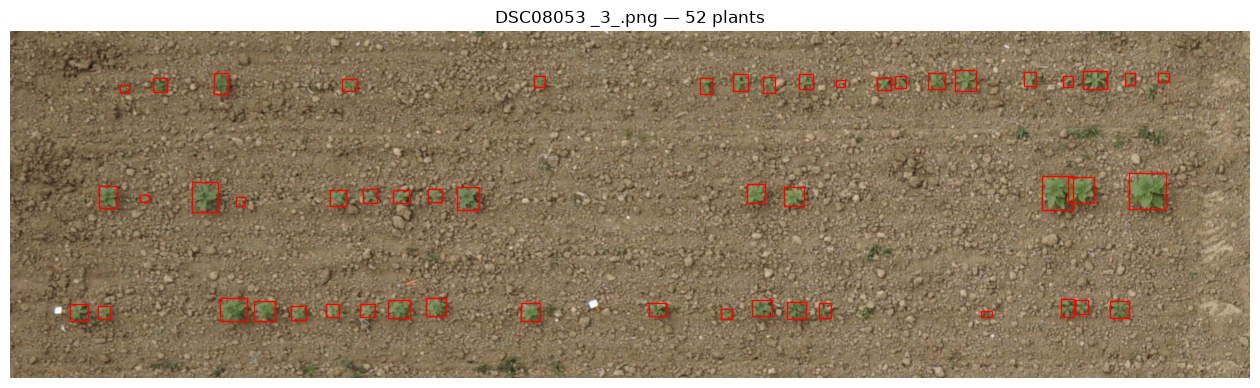

In [ ]:
# Visualisation of the image and its annotation

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Take first image as example

image_info = annotations["images"][0]
image_path = experiment_dir / image_info["file_name"]

# Import all annotations for this image

image_annotations = [
    annotation
    for annotation in annotations["annotations"]
    if annotation["image_id"] == image_info["id"]
]

print(f"Number of plants: {len(image_annotations)}")

# Plot the image with all bounding boxes

image = Image.open(image_path)

fig, ax = plt.subplots(figsize=(16, 6))

ax.imshow(image)

for annotation in image_annotations:
    x, y, width, height = annotation["bbox"]

    rectangle = Rectangle(
        (x, y),
        width,
        height,
        fill=False,
        edgecolor="red",
        linewidth=1,
    )

    ax.add_patch(rectangle)

ax.set_title(
    f"{image_info['file_name']} — "
    f"{len(image_annotations)} plants"
)

ax.axis("off")

plt.show()


In [ ]:
# Dataset summary

# The selected sunflower dataset contains 12 RGB images and 578 annotated 
# plants. Images have variable dimensions ranging from 
# 3657–4638 × 1013–1277 pixels. Each plant is represented by a bounding box, 
# with an average size of approximately 56.7 × 56.1 pixels. The number of annotated 
# plants per image ranges from 34 to 64, with a mean of 48.2 plants per image.


In [67]:
# Create functions to process other UAV data

def load_annotations(experiment_dir):
    """Load the annotation JSON associated with an experiment."""

    json_path = experiment_dir.parent / f"{experiment_dir.name}.json"

    with open(json_path, encoding="utf-8") as file:
        return json.load(file)

def summarize_experiment(experiment_dir):
    """Compute summary statistics for one UAV RGB experiment."""

    annotations = load_annotations(experiment_dir)

    images = annotations["images"]
    plant_annotations = annotations["annotations"]

    n_images = len(images)
    n_annotations = len(plant_annotations)

    # Number of plants per image
    plants_per_image = Counter(
        annotation["image_id"]
        for annotation in plant_annotations
    )

    plant_counts = np.array(list(plants_per_image.values()))

    # Image dimensions
    widths = np.array([
        image["width"]
        for image in images
    ])

    heights = np.array([
        image["height"]
        for image in images
    ])

    # Bounding box dimensions
    bbox_widths = np.array([
        annotation["bbox"][2]
        for annotation in plant_annotations
    ])

    bbox_heights = np.array([
        annotation["bbox"][3]
        for annotation in plant_annotations
    ])

    return {
        "experiment": experiment_dir.name,
        "crop": experiment_dir.parent.name,
        "n_images": n_images,
        "n_annotations": n_annotations,
        "plants_per_image_min": plant_counts.min(),
        "plants_per_image_max": plant_counts.max(),
        "plants_per_image_mean": round(plant_counts.mean(), 0),
        "plants_per_image_median": round(np.median(plant_counts), 0),
        "image_width_min": widths.min(),
        "image_width_max": widths.max(),
        "image_width_mean": round(widths.mean(), 1),
        "image_height_min": heights.min(),
        "image_height_max": heights.max(),
        "image_height_mean": round(heights.mean(), 1),
        "bbox_width_min": bbox_widths.min(),
        "bbox_width_max": bbox_widths.max(),
        "bbox_width_mean": round(bbox_widths.mean(), 1),
        "bbox_height_min": bbox_heights.min(),
        "bbox_height_max": bbox_heights.max(),
        "bbox_height_mean": round(bbox_heights.mean(), 1),
    }

In [68]:
# Try on current directory

annotations = load_annotations(experiment_dir)

print(annotations.keys())

summary = summarize_experiment(experiment_dir)

summary

dict_keys(['categories', 'images', 'annotations'])


{'experiment': '3_rivière_2017_1',
 'crop': 'sunflower',
 'n_images': 8,
 'n_annotations': 634,
 'plants_per_image_min': np.int64(61),
 'plants_per_image_max': np.int64(101),
 'plants_per_image_mean': np.float64(79.0),
 'plants_per_image_median': np.float64(78.0),
 'image_width_min': np.int64(1568),
 'image_width_max': np.int64(1772),
 'image_width_mean': np.float64(1716.5),
 'image_height_min': np.int64(1087),
 'image_height_max': np.int64(1416),
 'image_height_mean': np.float64(1309.6),
 'bbox_width_min': np.float64(43.0),
 'bbox_width_max': np.float64(180.0),
 'bbox_width_mean': np.float64(100.1),
 'bbox_height_min': np.float64(39.0),
 'bbox_height_max': np.float64(176.0),
 'bbox_height_mean': np.float64(101.6)}

In [69]:
# Loop summary over all directories
print(list(dataset_dir.glob("*")))
print(list(dataset_dir.glob("*/*"))[:10])

experiment_dirs = []

for crop_dir in dataset_dir.iterdir():
    if crop_dir.is_dir():
        for plot_dir in crop_dir.iterdir():
            if plot_dir.is_dir():
                json_path = crop_dir / f"{plot_dir.name}.json"
                if json_path.exists():
                    experiment_dirs.append(plot_dir)


print(f"Number of experiments: {len(experiment_dirs)}")
for experiment_dir in experiment_dirs:
    print(experiment_dir)

summaries = [
    summarize_experiment(experiment_dir)
    for experiment_dir in experiment_dirs
]

[WindowsPath('c:/Users/aurel/Documents/GitHub/OpenCropPhenotyping/data/raw/UAVmulticrop/maize'), WindowsPath('c:/Users/aurel/Documents/GitHub/OpenCropPhenotyping/data/raw/UAVmulticrop/sugarbeet'), WindowsPath('c:/Users/aurel/Documents/GitHub/OpenCropPhenotyping/data/raw/UAVmulticrop/sunflower'), WindowsPath('c:/Users/aurel/Documents/GitHub/OpenCropPhenotyping/data/raw/UAVmulticrop/table_handcraftpaper.csv')]
[WindowsPath('c:/Users/aurel/Documents/GitHub/OpenCropPhenotyping/data/raw/UAVmulticrop/maize/1_hermine_2019_1'), WindowsPath('c:/Users/aurel/Documents/GitHub/OpenCropPhenotyping/data/raw/UAVmulticrop/maize/1_hermine_2019_1.json'), WindowsPath('c:/Users/aurel/Documents/GitHub/OpenCropPhenotyping/data/raw/UAVmulticrop/maize/1_selommes_2019_1'), WindowsPath('c:/Users/aurel/Documents/GitHub/OpenCropPhenotyping/data/raw/UAVmulticrop/maize/1_selommes_2019_1.json'), WindowsPath('c:/Users/aurel/Documents/GitHub/OpenCropPhenotyping/data/raw/UAVmulticrop/maize/1_thenay_2017_1'), WindowsPath

In [70]:
# Display summaries in a panda table

import pandas as pd

summary_df = pd.DataFrame(summaries)
summary_df

,experiment,crop,n_images,n_annotations,plants_per_image_min,plants_per_image_max,plants_per_image_mean,plants_per_image_median,image_width_min,image_width_max,image_width_mean,image_height_min,image_height_max,image_height_mean,bbox_width_min,bbox_width_max,bbox_width_mean,bbox_height_min,bbox_height_max,bbox_height_mean
0,1_hermine_2019_1,maize,4,542,131,141,136.0,135.0,2402,2412,2407.2,1288,1303,1293.5,8.0,81.0,31.9,7.0,71.0,32.7
1,1_selommes_2019_1,maize,7,510,48,88,73.0,76.0,2403,2417,2411.7,645,733,695.6,7.0,64.0,25.1,6.0,70.0,27.6
2,1_thenay_2017_1,maize,6,617,83,118,103.0,106.0,1502,1786,1690.5,1500,1752,1675.8,9.0,80.0,36.4,6.0,83.0,35.3
3,2_blois_2019_1,maize,7,579,69,93,83.0,82.0,2217,3121,2612.6,568,889,719.1,15.0,98.0,46.3,12.0,117.0,54.7
4,2_castetis_2019_1,maize,5,575,112,116,115.0,116.0,1597,1792,1720.8,1079,1261,1157.4,13.0,109.0,43.0,11.0,85.0,40.7
5,2_pleinefougeres_2019_1,maize,2,504,251,253,252.0,252.0,4802,4812,4807.0,1293,1298,1295.5,13.0,154.0,46.7,11.0,95.0,50.0
6,3_menainville_2016_1,maize,6,620,98,110,103.0,102.0,3086,4187,3571.2,574,931,707.3,11.0,120.0,51.4,11.0,137.0,51.9
7,3_nerac_2016_1,maize,8,594,61,82,74.0,76.0,2661,2969,2864.8,707,1058,870.0,14.0,127.0,58.0,14.0,127.0,68.0
8,3_villedieu_2016_1,maize,6,716,99,135,119.0,120.0,3322,3702,3508.5,496,604,539.7,9.0,142.0,62.2,11.0,155.0,65.9
9,1_charmont_2018_1,sugarbeet,7,556,78,82,79.0,79.0,2311,2353,2328.7,594,628,610.4,15.0,76.0,46.7,19.0,82.0,46.3


In [66]:
# Explore the dataframe

summary_df.head()
summary_df.info()
print(summary_df["experiment"].tolist)
summary_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   experiment               27 non-null     str    
 1   n_images                 27 non-null     int64  
 2   n_annotations            27 non-null     int64  
 3   plants_per_image_min     27 non-null     int64  
 4   plants_per_image_max     27 non-null     int64  
 5   plants_per_image_mean    27 non-null     float64
 6   plants_per_image_median  27 non-null     float64
 7   image_width_min          27 non-null     int64  
 8   image_width_max          27 non-null     int64  
 9   image_width_mean         27 non-null     float64
 10  image_height_min         27 non-null     int64  
 11  image_height_max         27 non-null     int64  
 12  image_height_mean        27 non-null     float64
 13  bbox_width_min           27 non-null     float64
 14  bbox_width_max           27 non-null   

,n_images,n_annotations,plants_per_image_min,plants_per_image_max,plants_per_image_mean,plants_per_image_median,image_width_min,image_width_max,image_width_mean,image_height_min,image_height_max,image_height_mean,bbox_width_min,bbox_width_max,bbox_width_mean,bbox_height_min,bbox_height_max,bbox_height_mean
count,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000
mean,7.000000,597.111111,88.925926,111.074074,101.111111,101.703704,2899.629630,3258.407407,3077.122222,891.259259,1088.666667,990.648148,16.851852,127.444444,60.885185,17.111111,136.407407,63.688889
std,2.882307,66.520866,48.238132,48.288337,47.333785,47.361795,834.055345,954.909914,868.868834,304.248834,295.462870,299.013880,8.623330,50.202922,23.420614,9.617026,66.483809,25.197151
min,2.000000,385.000000,29.000000,60.000000,47.000000,48.000000,1502.000000,1772.000000,1690.500000,496.000000,604.000000,539.700000,7.000000,59.000000,25.100000,6.000000,70.000000,27.600000
25%,6.000000,562.500000,61.000000,82.500000,76.500000,77.000000,2340.000000,2414.500000,2408.050000,599.000000,910.000000,750.800000,12.500000,89.000000,45.800000,11.000000,86.000000,47.800000
50%,6.000000,602.000000,83.000000,101.000000,93.000000,94.000000,3027.000000,3190.000000,3133.200000,891.000000,1096.000000,963.500000,15.000000,120.000000,56.700000,15.000000,127.000000,56.100000
75%,8.000000,637.500000,102.000000,117.000000,112.000000,113.500000,3400.000000,4013.000000,3596.450000,1073.500000,1269.000000,1154.100000,18.000000,148.000000,77.050000,19.000000,156.500000,80.500000
max,12.000000,716.000000,251.000000,253.000000,252.000000,252.000000,4802.000000,4931.000000,4807.000000,1500.000000,1752.000000,1675.800000,43.000000,279.000000,109.100000,45.000000,372.000000,114.800000


In [74]:
# Display some of the caracteristics of the dataset with plotly

import plotly.express as px

fig = px.histogram(
    summary_df,
    x="plants_per_image_mean",
    nbins=10,
    title="Distribution of mean number of plants per image",
)

fig.show()

fig = px.bar(
    summary_df,
    x="experiment",
    y="plants_per_image_mean",
    title="Mean number of plants per image by experiment",
)

fig.show()

In [75]:
# Number of plants per image and distinguish by crop species

fig = px.scatter(
    summary_df,
    x="n_images",
    y="n_annotations",
    color="crop",
    hover_data=[
        "plants_per_image_mean",
        "image_width_mean",
        "image_height_mean",
    ],
    title="Number of images and annotations per experiment",
)

fig.show() 

fig = px.box(
    summary_df,
    x="crop",
    y="plants_per_image_mean",
    points="all",
    title="Mean number of plants per image by crop",
)

fig.show()

In [ ]:
# Dataset characterization

# The UAVmulticrop dataset used for the RGB imagery workflow contains 
# 27 experiments covering maize, sugar beet and sunflower. 
# Each experiment contains RGB images of variable dimensions and 
# associated plant annotations provided as bounding boxes.

# The dataset contains approximately 7 images per experiment on average, 
# with substantial variation in image dimensions and plant density. 
# Each annotated plant is represented by a bounding box, making the dataset 
# suitable for exploring RGB-based vegetation analysis, plant detection and 
# segmentation workflows.

# The dataset was also checked for annotation completeness and consistency, 
# with all images associated with valid annotations and no orphan 
# annotation references.